In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('diabetes.csv')

# 1) EDA

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

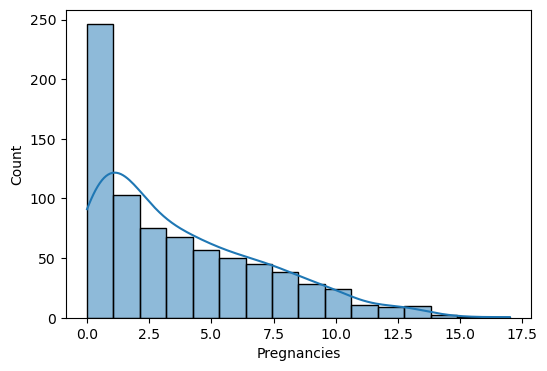

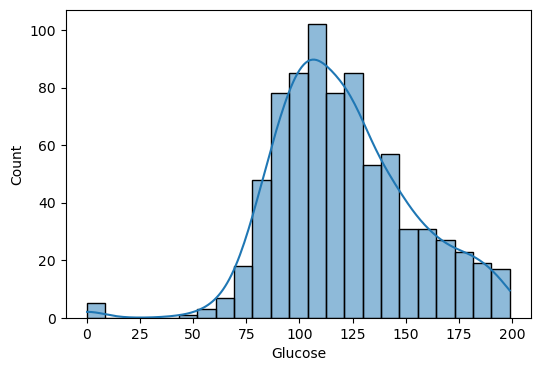

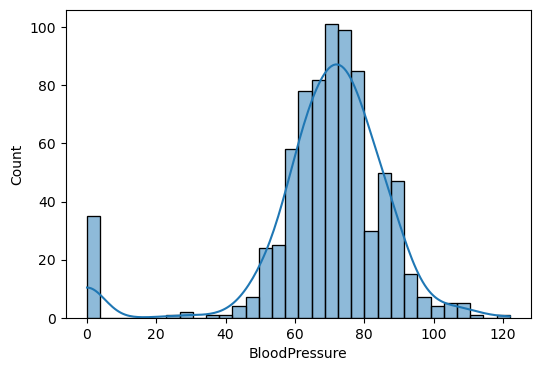

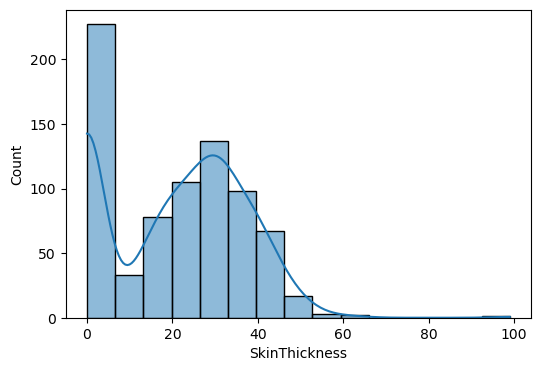

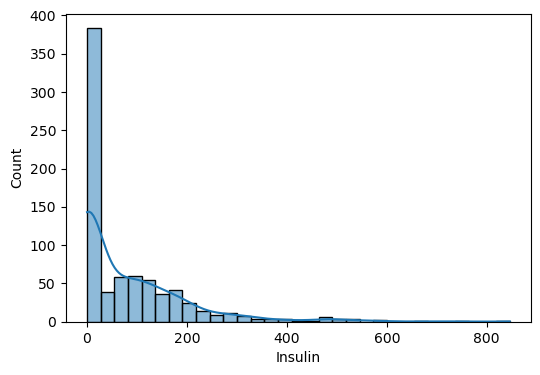

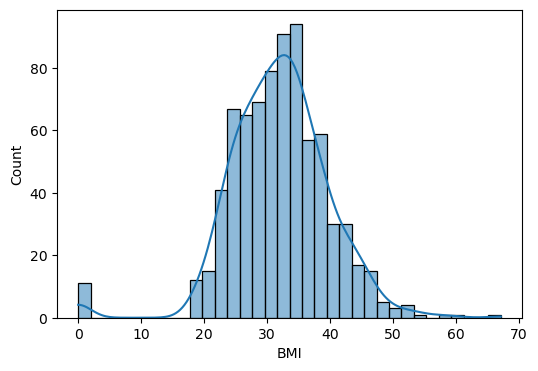

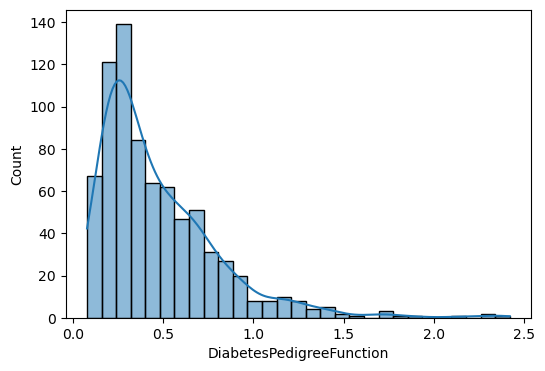

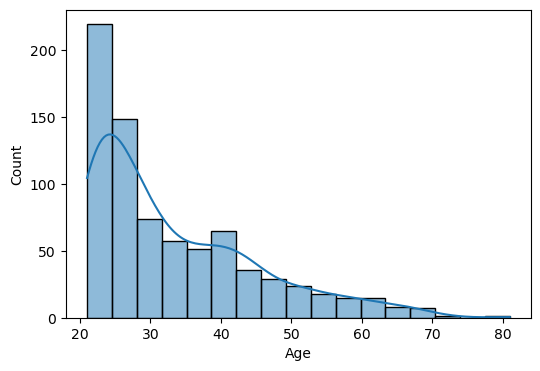

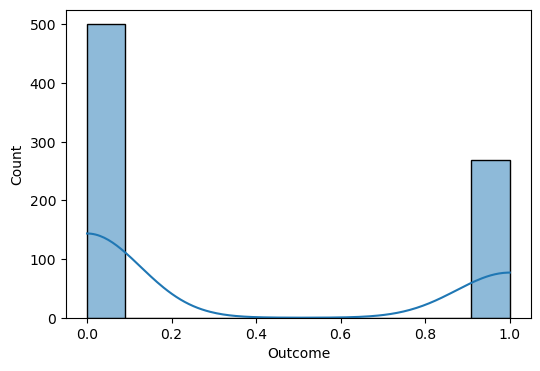

In [9]:
col=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
for i in col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True)

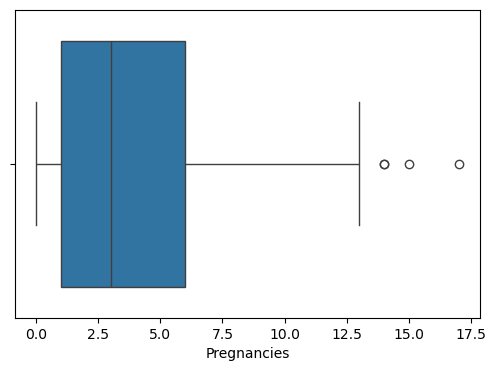

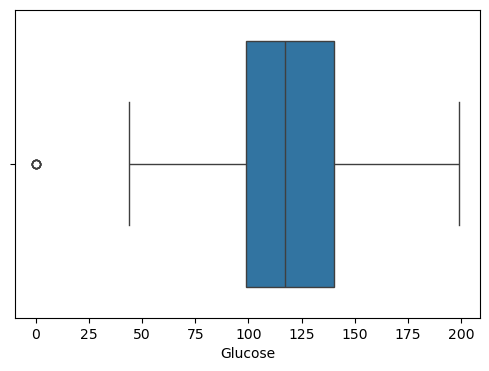

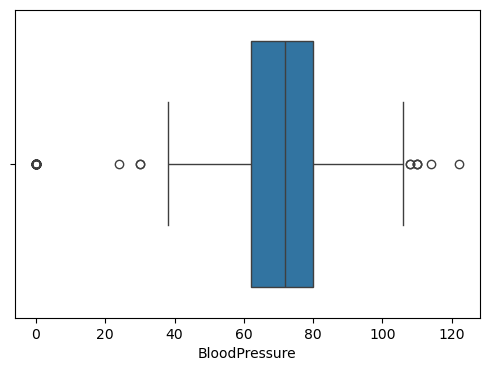

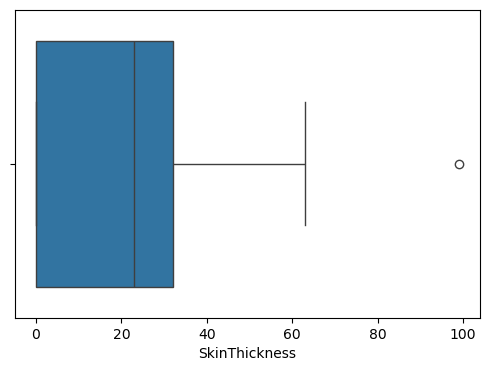

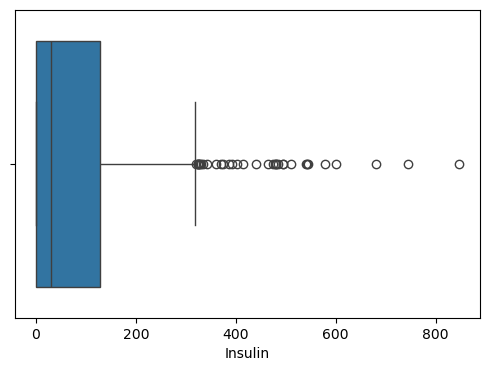

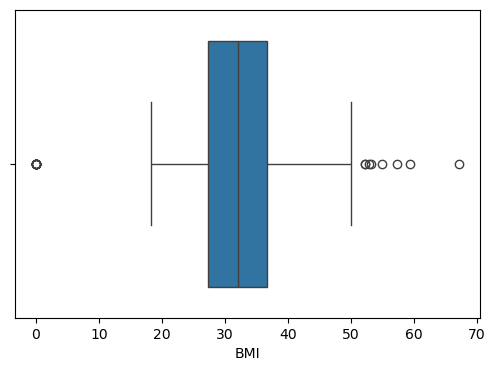

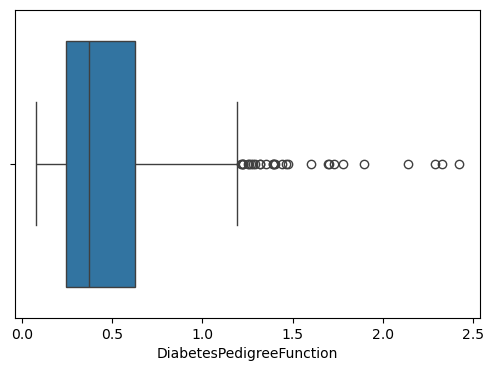

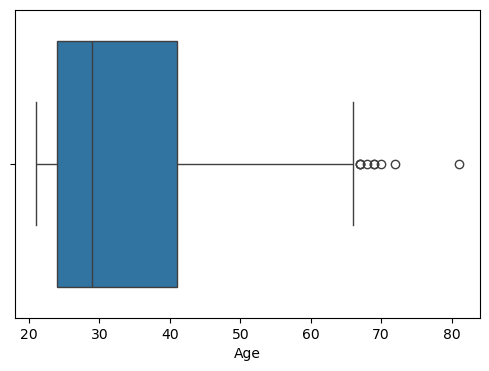

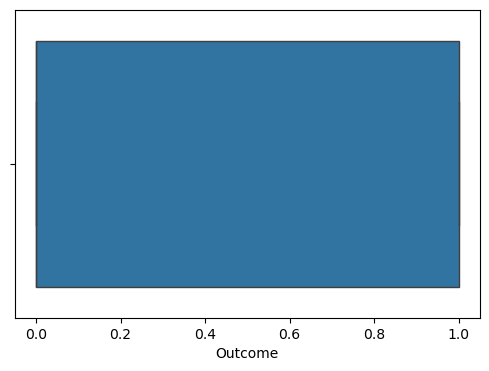

In [10]:
for i in col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i])

<Axes: >

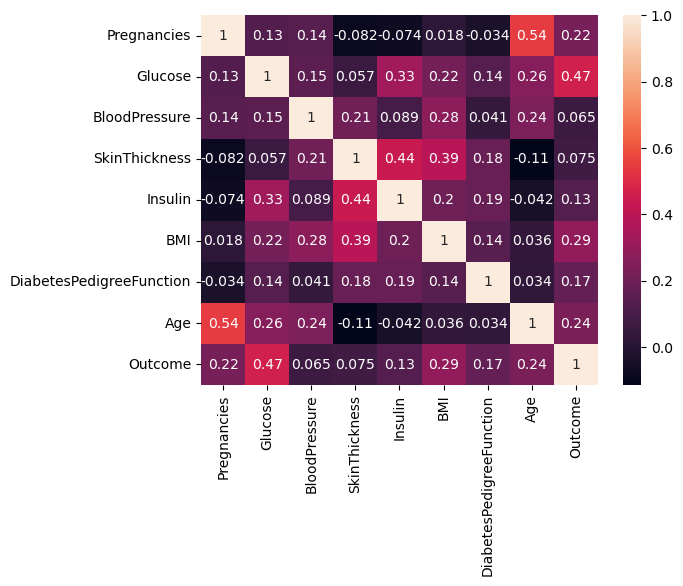

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

#### no need of data preprocessing bcz the data is already processed.

# 2) Model Building

In [12]:
x=df.drop('Outcome',axis = 1)
y=df['Outcome']

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### XG boost

In [15]:
import xgboost as xgb

In [16]:
model=xgb.XGBClassifier()

In [17]:
model.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [18]:
y_pred=model.predict(x_test)

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.metrics import  precision_score, recall_score, f1_score,  ConfusionMatrixDisplay


In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        99
           1       0.56      0.67      0.61        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.69      0.70       154



### light boost

In [21]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [22]:
import lightgbm as lgb

In [23]:
model1=lgb.LGBMClassifier()

In [24]:
model1.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000551 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [25]:
y_pred1=model1.predict(x_test)

In [26]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.81      0.74      0.77        99
           1       0.59      0.69      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.72      0.72       154



### grid search cv for both

In [27]:
modelx = xgb.XGBClassifier()

param_grid={
    'n_estimators':[75,100,150],
    'learning_rate':[0.1,0.3,0.5],
    'max_depth':[4,6,8]
}

In [28]:
from sklearn.model_selection import GridSearchCV



grid_search=GridSearchCV(
    estimator=modelx,
    param_grid=param_grid,
     cv=5,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.1, 0.3, ...], 'max_depth': [4, 6, ...], 'n_estimators': [75, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [29]:

print("Best Parameters:", grid_search.best_params_)

print("Best Cross-Validation Accuracy:", grid_search.best_score_)


best_model = grid_search.best_estimator_

Best Parameters: {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 75}
Best Cross-Validation Accuracy: 0.767119818739171


### grid_search for light boosting

In [30]:
modell=lgb.LGBMClassifier()

param_grid={
    'n_estimators':[75,100,150],
    'learning_rate':[0.1,0.3,0.5],
    'max_depth':[4,6,8]
}

In [31]:
from sklearn.model_selection import GridSearchCV



grid_search1 = GridSearchCV(
    estimator=modell,
    param_grid=param_grid,
     cv=5,
    scoring='accuracy'
)

grid_search1.fit(x_train, y_train)


[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 578
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,estimator,LGBMClassifier()
,param_grid,"{'learning_rate': [0.1, 0.3, ...], 'max_depth': [4, 6, ...], 'n_estimators': [75, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [32]:

print("Best Parameters:", grid_search1.best_params_)

print("Best Cross-Validation Accuracy:", grid_search1.best_score_)


best_model = grid_search1.best_estimator_

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.7769025723044116


In [33]:
# Default models
y_pred_xgb = model.predict(x_test)
y_pred_lgb = model1.predict(x_test)

# Tuned models (best estimators from GridSearchCV)
y_pred_xgb_tuned = grid_search.best_estimator_.predict(x_test)
y_pred_lgb_tuned = grid_search1.best_estimator_.predict(x_test)

In [35]:
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

In [36]:
results = {
    'XGBoost (Default)': compute_metrics(y_test, y_pred_xgb),
    'LightGBM (Default)': compute_metrics(y_test, y_pred_lgb),
    'XGBoost (Tuned)': compute_metrics(y_test, y_pred_xgb_tuned),
    'LightGBM (Tuned)': compute_metrics(y_test, y_pred_lgb_tuned)
}

df_results = pd.DataFrame(results).T
print("\n===== COMPARISON METRICS =====\n")
print(df_results.round(4))


===== COMPARISON METRICS =====

                    Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
XGBoost (Default)     0.6948             0.6780          0.6899      0.6801
LightGBM (Default)    0.7208             0.7024          0.7141      0.7056
XGBoost (Tuned)       0.7338             0.7141          0.7242      0.7175
LightGBM (Tuned)      0.7338             0.7126          0.7202      0.7155


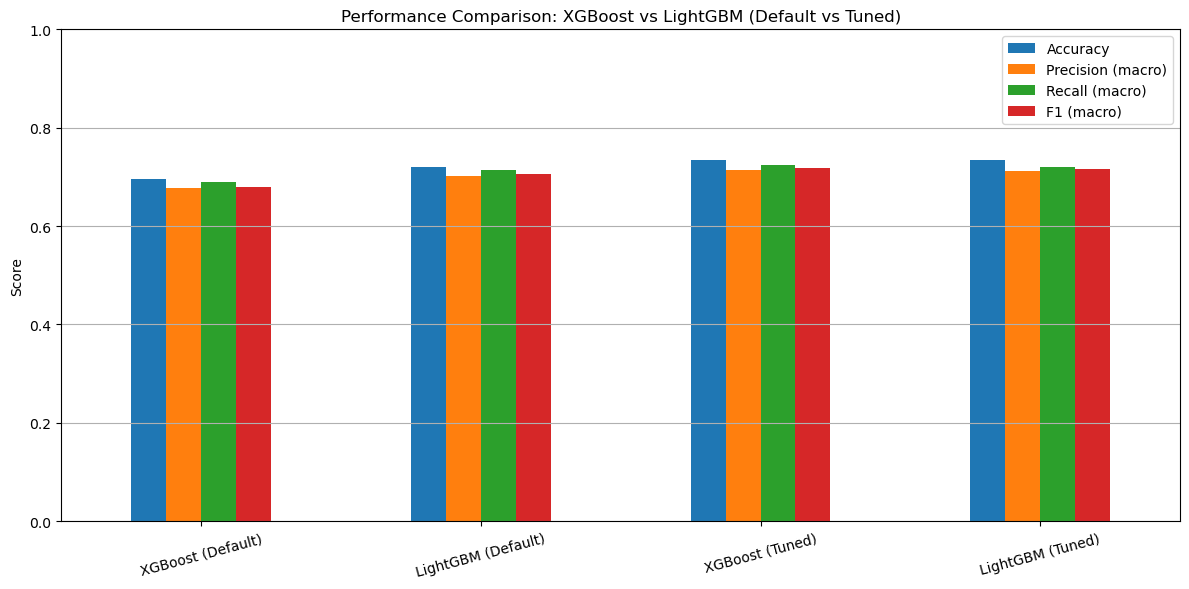

In [37]:
df_results.plot(kind='bar', figsize=(12, 6))
plt.title('Performance Comparison: XGBoost vs LightGBM (Default vs Tuned)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

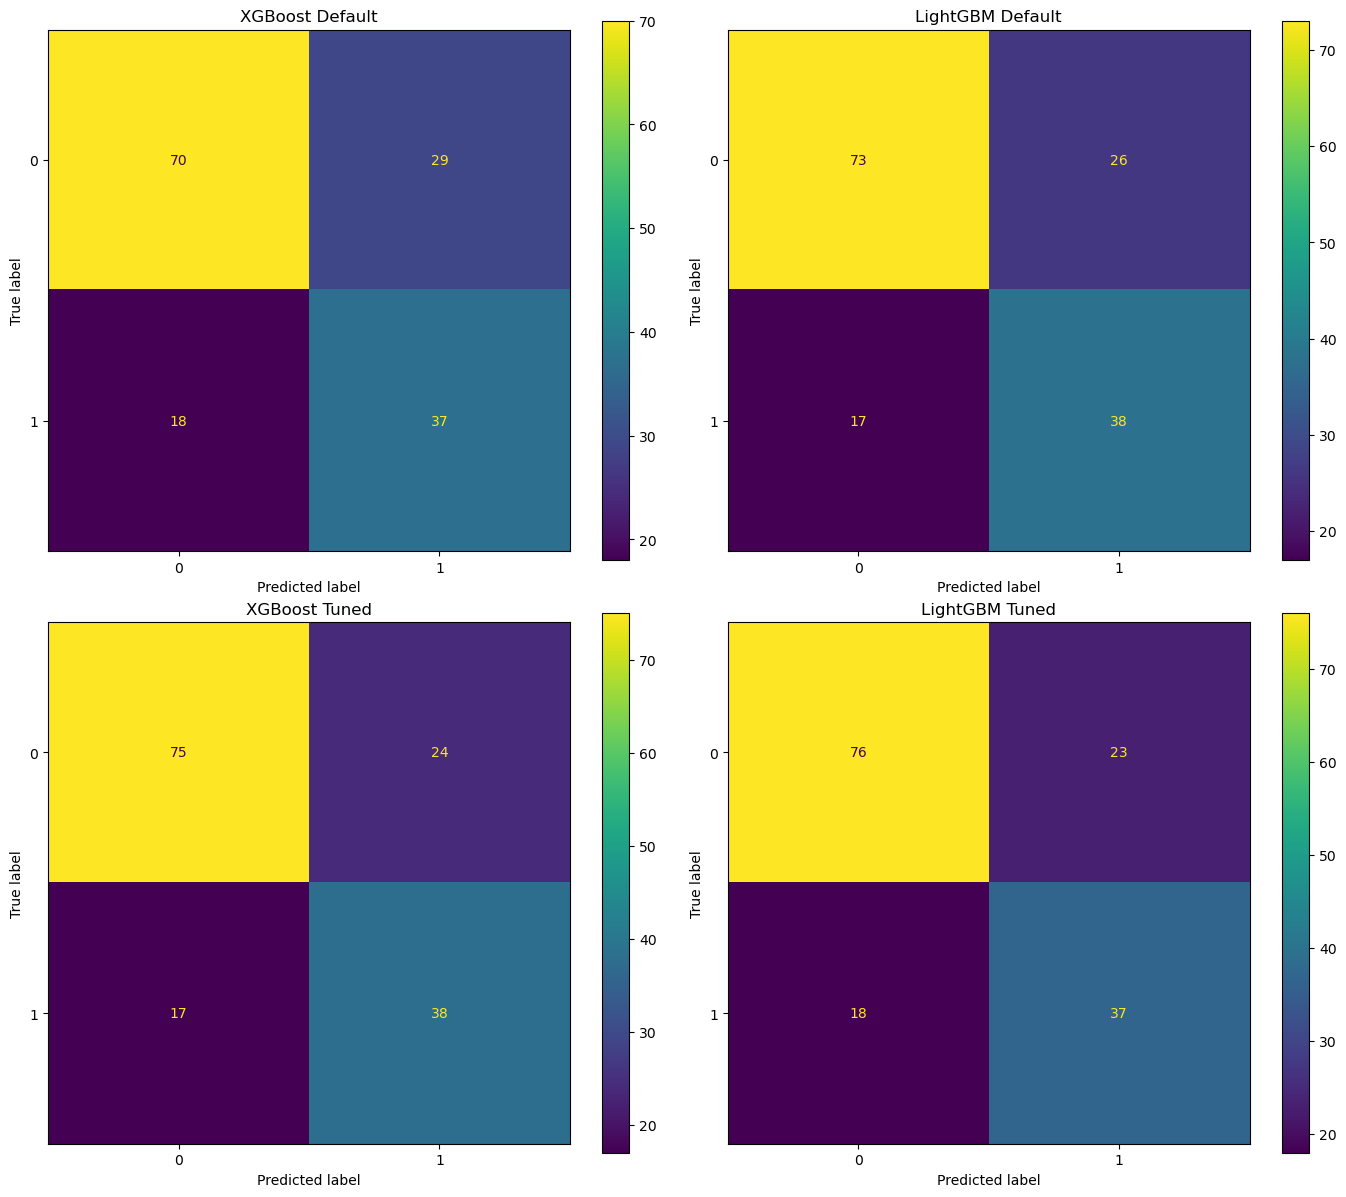

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

models_and_preds = [
    ('XGBoost Default', y_pred_xgb),
    ('LightGBM Default', y_pred_lgb),
    ('XGBoost Tuned', y_pred_xgb_tuned),
    ('LightGBM Tuned', y_pred_lgb_tuned)
]

for ax, (name, preds) in zip(axes.flat, models_and_preds):
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

#### Firstly we saw the accuracy of xgboost we got the accuracy of 69% and of light boost it came 72%,  but after hypertuning both the model gave the accuracy to 71 % , so the tuned model of  light has Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100} and that of xgb has Best Parameters: {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 75} 